# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [36]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [ ]:
from google.colab import files
uploaded = files.upload()

In [48]:
# Load datasets
demographics = pd.read_csv('../data/patient_demographics - patient_demographics.csv')
clinical = pd.read_csv("../data/clinical_data.csv")
lifestyle = pd.read_csv("../data/lifestyle_factors.csv")

In [49]:
demographics

,Patient ID,Age,Sex,Income,Unnamed: 4,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BCountryNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere
...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,235420,Thailand,Asia,Northern Hemisphere
8759,QSV6764,28,Female,217881,Canada,North America,Northern Hemisphere
8760,XKA5925,47,Male,36998,Brazil,South America,Southern Hemisphere
8761,EPE6801,36,Male,209943,Brazil,South America,Southern Hemisphere


In [50]:
clinical

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144
...,...,...,...,...,...,...,...,...
8758,MSV9918,121,94/76,61,1,1,67,19.655895
8759,QSV6764,120,157/102,73,1,0,617,23.993866
8760,XKA5925,250,161/75,105,0,1,527,35.406146
8761,EPE6801,178,119/67,60,1,0,114,27.294020


In [51]:
lifestyle

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0
...,...,...,...,...,...,...,...,...
8758,MSV9918,1,0,1,7.917342,Healthy,8,0
8759,QSV6764,0,1,0,16.558426,Healthy,8,0
8760,XKA5925,1,1,1,3.148438,Average,5,1
8761,EPE6801,1,0,0,3.789950,Unhealthy,5,0


# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [53]:
demographics.sample(5)

,Patient ID,Age,Sex,Income,Unnamed: 4,Continent,Hemisphere
4342,NUD6180,72,Male,172093,Italy,Europe,Southern Hemisphere
7782,NSA4283,59,Male,187641,Japan,Asia,Northern Hemisphere
2461,AUT7517,87,Female,256040,Canada,North America,Northern Hemisphere
6465,WFY6336,45,Male,217213,Germany,Europe,Northern Hemisphere
5843,IUD0393,90,Female,213732,China,Asia,Northern Hemisphere


In [56]:
lifestyle.sample(5)

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
8573,CFZ8337,1,1,1,3.568417,Healthy,2,0
6922,UVF6873,1,0,1,3.343710,Unhealthy,9,0
4195,XTS5559,1,1,1,5.503465,Average,5,0
787,ADW2761,1,0,1,0.770203,Healthy,2,1
3817,DGM3203,1,1,1,19.942891,Average,10,0


In [58]:
clinical.sample(5)

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
5738,VHT2026,381,128/96,41,1,1,693,27.806442
7678,OED0456,397,121/79,71,1,1,254,29.523067
3576,PZG0622,340,142/90,100,1,0,751,39.117160
2882,YLL5287,361,147/88,84,1,1,356,24.167016
6564,VQI4944,270,100/68,110,0,0,589,30.756830


In [61]:
# Your code here
print(demographics.info())
print("--"*50)
print(lifestyle.info())
print("--"*50)
print(clinical.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Patient ID  8763 non-null   object
 1   Age         8763 non-null   int64 
 2   Sex         8763 non-null   object
 3   Income      8763 non-null   int64 
 4   Unnamed: 4  8763 non-null   object
 5   Continent   8763 non-null   object
 6   Hemisphere  8763 non-null   object
dtypes: int64(2), object(5)
memory usage: 479.4+ KB
None
----------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   object 
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  


In [64]:
# Your code here
print(demographics.describe)
print('-'*50)
print(lifestyle.describe)
print('-'*50)
print(clinical.describe)


<bound method NDFrame.describe of           Patient ID  Age     Sex  Income      Unnamed: 4      Continent  \
0            BMW7812   67    Male  261404       Argentina  South America   
1            CZE1114   21    Male  285768          Canada  North America   
2     BCountryNI9906   21  Female  235282          France         Europe   
3            JLN3497   84    Male  125640          Canada  North America   
4            GFO8847   66    Male  160555        Thailand           Asia   
...              ...  ...     ...     ...             ...            ...   
8758         MSV9918   60    Male  235420        Thailand           Asia   
8759         QSV6764   28  Female  217881          Canada  North America   
8760         XKA5925   47    Male   36998          Brazil  South America   
8761         EPE6801   36    Male  209943          Brazil  South America   
8762         ZWN9666   25  Female  247338  United Kingdom         Europe   

               Hemisphere  
0     Southern Hemisphere

In [ ]:
# Your code here

# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [ ]:
# Your code here
clinical.dtypes
# so the Blood pressure is a string object, we can use string operations to split 

Patient ID         object
Cholesterol         int64
Blood Pressure     object
Heart Rate          int64
Diabetes            int64
Family History      int64
Triglycerides       int64
BMI               float64
dtype: object

In [71]:
# Your code here
clinical['Blood Pressure']


0        158/88
1        165/93
2        174/99
3       163/100
4         91/88
         ...   
8758      94/76
8759    157/102
8760     161/75
8761     119/67
8762     138/67
Name: Blood Pressure, Length: 8763, dtype: object

In [72]:
# Your code here
clinical['Blood Pressure'] = clinical['Blood Pressure'].str.split()

In [ ]:
clinical['Blood Pressure']
# ok the job is done 

0        [158/88]
1        [165/93]
2        [174/99]
3       [163/100]
4         [91/88]
          ...    
8758      [94/76]
8759    [157/102]
8760     [161/75]
8761     [119/67]
8762     [138/67]
Name: Blood Pressure, Length: 8763, dtype: object

## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [75]:
# Your code here
demographics.isnull().sum()

Patient ID    0
Age           0
Sex           0
Income        0
Unnamed: 4    0
Continent     0
Hemisphere    0
dtype: int64

In [76]:
# Your code here
lifestyle.isnull().sum()


Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64

In [78]:
# Your code here
clinical.isnull().sum()
# no missing values so moving onnn

Patient ID        0
Cholesterol       0
Blood Pressure    0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
dtype: int64

# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


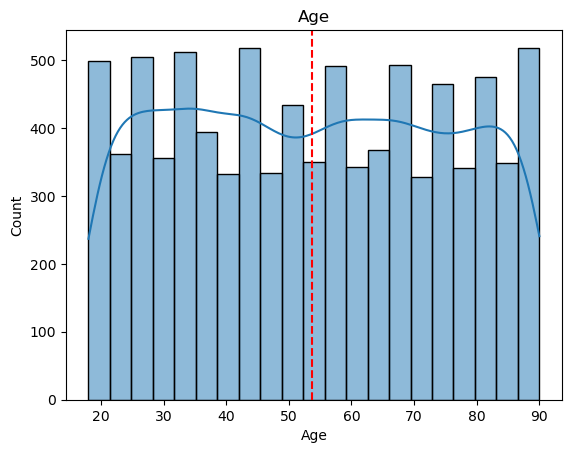

In [ ]:
# Your code here
# for age 
sns.histplot(data = demographics, x='Age' , kde=True)
plt.axvline(demographics['Age'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Age')
plt.show()

In [85]:
clinical

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,[158/88],72,0,0,286,31.251233
1,CZE1114,389,[165/93],98,1,1,235,27.194973
2,BNI9906,324,[174/99],72,1,0,587,28.176571
3,JLN3497,383,[163/100],73,1,1,378,36.464704
4,GFO8847,318,[91/88],93,1,1,231,21.809144
...,...,...,...,...,...,...,...,...
8758,MSV9918,121,[94/76],61,1,1,67,19.655895
8759,QSV6764,120,[157/102],73,1,0,617,23.993866
8760,XKA5925,250,[161/75],105,0,1,527,35.406146
8761,EPE6801,178,[119/67],60,1,0,114,27.294020


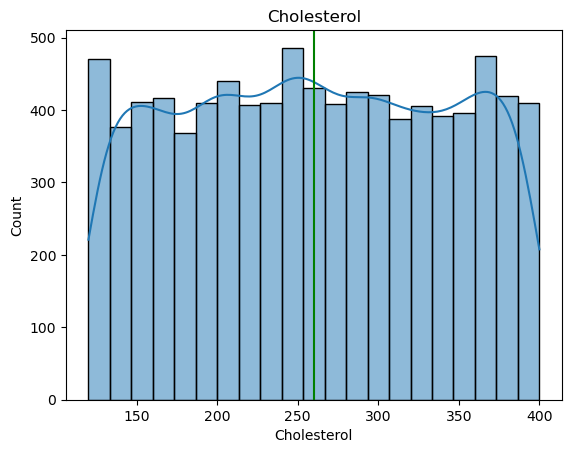

In [91]:
# Your code here
# for Cholesterol
sns.histplot(data = clinical, x='Cholesterol' , kde=True)
plt.axvline(clinical['Cholesterol'].mean(), color='green', linestyle='-', label='Mean')
plt.title('Cholesterol')
plt.show()

In [ ]:
# Your code here
# for BMI
sns.histplot(data = clinical, x='BMI' , kde=True)
plt.axvline(clinical['Cholesterol'].mean(), color='green', linestyle='-', label='Mean')
plt.title('Cholesterol')
plt.show()

## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here

# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

### Answer here: